# EDIS 8100 · Week 4 · Mini Project 1 · 30-minute version · INSTRUCTOR COPY

> **Instructor copy.** Identical to the student notebook except that the critique table
> near the end is filled in. The student version is `week04_teacher_dashboard_30min.ipynb`.

## Building a teacher dashboard on real student records, and reading it critically

Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia

This is the short version of the Week 4 notebook. It builds two panels of a teacher-facing dashboard for a module team (i.e., the chair, tutors, and retention staff who run one course) with one week of outreach time (i.e., they can contact about 150 students before the next week arrives) and 2,237 enrollments (i.e., one person taking one module one time), and then asks what each panel would lead a teacher to do and where it would mislead them.

Every cell already contains working code. There is no expectation that you write code from scratch in this course. Your attention is better spent on what the output might mean. Questions about a single line are welcome at any point.

## Where this data comes from

| | |
|---|---|
| **Dataset** | Open University Learning Analytics Dataset (OULAD), module **BBB**, presentations **2013J** and **2014J**. A presentation is one run of a module, so 2013J is the October 2013 cohort and 2014J the October 2014 cohort of the same course. |
| **Who collected it** | The Open University, a large distance-teaching university in the United Kingdom. Its Knowledge Media Institute assembled administrative and virtual learning environment records (i.e., the logs from the online site where the course is taught) for seven modules. |
| **What was removed** | Names and direct identifiers (i.e., anything that points at one person, such as a student number). The demographic fields were coarsened into bands (i.e., an exact age replaced by an age range). Released in 2017 for research use outside the university (Kuzilek, Hlosta, and Zdrahal, 2017). |
| **License** | CC BY 4.0. Use, share, and adapt it, including commercially, as long as you credit the source. |
| **Citation** | Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2017). Open University Learning Analytics dataset. *Scientific Data, 4*, 170171. |
| **The people in it** | Students at a university that requires no previous qualifications for entry. They are told at admission that their data are used for research and may be shared with other researchers, and the Open University offers no opt-out from learning analytics research. |

**Run the cell below.** It fetches six files and reports what arrived.

In [1]:
%matplotlib inline

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)

# A colorblind-safe palette (Okabe and Ito). Every color distinction below is
# backed up by a shape or a label.
BLUE, ORANGE, SKY, PURPLE, GREY, VERM, GREEN = (
    "#0072b2", "#e69f00", "#56b4e9", "#cc79a7", "#7f7f7f", "#d55e00", "#009e73")

BASE = "https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/main"

TABLES = {
    "student_info":       ("studentInfo.csv",        "one enrollment: who registered, and how it ended"),
    "student_vle":        ("studentVle.csv.gz",      "one student, one resource, one day: how many clicks"),
    "student_assessment": ("studentAssessment.csv",  "one submitted assessment"),
    "assessments":        ("assessments.csv",        "one assessment: its type, due day, and weight"),
    "registration":       ("studentRegistration.csv","one enrollment: when they signed up, when they left"),
}

try:
    raw = {key: pd.read_csv(f"{BASE}/oulad-bbb/{fname}") for key, (fname, _) in TABLES.items()}
except Exception as err:
    print("  The download did not work, so nothing below this cell will run yet.")
    print("  Check that this runtime has internet, then run the cell again.")
    print(f"  The underlying message, for your instructor: {type(err).__name__}: {err}")
    raise SystemExit("Could not download the course datasets.")

student_info       = raw["student_info"]
student_vle        = raw["student_vle"]
student_assessment = raw["student_assessment"]
assessments        = raw["assessments"]
registration       = raw["registration"]

print("=" * 76)
print("  Open University Learning Analytics Dataset, module BBB, 2013J and 2014J")
print("  Kuzilek, Hlosta, and Zdrahal (2017), Scientific Data 4:170171 - CC BY 4.0")
print("=" * 76)
for key, (fname, grain) in TABLES.items():
    df = raw[key]
    print(f"  {fname:<24} {len(df):>9,} rows x {df.shape[1]:>2}   {grain}")
print("=" * 76)
print(f"  {len(student_info):,} enrollments in two runs of one module:")
for pres, n in student_info["code_presentation"].value_counts().sort_index().items():
    print(f"      {pres}   {n:>6,} students")
print("=" * 76)

  Open University Learning Analytics Dataset, module BBB, 2013J and 2014J
  Kuzilek, Hlosta, and Zdrahal (2017), Scientific Data 4:170171 - CC BY 4.0
  studentInfo.csv              4,529 rows x 12   one enrollment: who registered, and how it ended
  studentVle.csv.gz          891,062 rows x  6   one student, one resource, one day: how many clicks
  studentAssessment.csv       21,783 rows x  5   one submitted assessment
  assessments.csv                 18 rows x  6   one assessment: its type, due day, and weight
  studentRegistration.csv      4,529 rows x  5   one enrollment: when they signed up, when they left
  4,529 enrollments in two runs of one module:
      2013J    2,237 students
      2014J    2,292 students


## Part A. What was done to the file before any chart

A dashboard inherits every limit of the data underneath it, and a clean layout makes those limits hard to see. That is one common way a dashboard misleads: it looks complete.

This export (i.e., the file the university's systems produced, before anybody tidied it) has irregularities that a teaching example usually removes. They are kept, and handled in public, because the decisions change what the dashboard says. Five of them, each in one line:

- **The deprivation column.** `imd_band` (i.e., the band of the area a student lived in) writes nine of its ten bands with a percent sign and one without, and 29 enrollments have it blank. Stripped the sign, mapped all ten to deciles 1 to 10 (i.e., tenths of a national ranking, where decile 1 is the most deprived tenth of neighborhoods), and kept the blanks in a visible "Not recorded" group.
- **Enrollments with no clicks.** 738 have no row anywhere in the clickstream (i.e., the log of activity in the online course site). Counts filled with 0 and a separate marker kept, because a 0 in the table is a measurement and an absence is not, and this file cannot tell you which you have.
- **Enrollments with no first assignment.** More than a thousand have no score, and 50 results were carried over from an earlier run of the module. Score filled with 0, a yes-or-no column added saying whether a score exists at all, and the carried-over results set aside.
- **Clicks before the module opens.** Module content is available before the official start, so some click rows are dated before day 0. The early window counts only days 0 to 29.
- **Fail and Withdrawn.** Separate outcomes in the registry (i.e., the university office that records them), treated here as one. A teacher's outreach list does not distinguish them either.

**One more, and it comes back.** Hundreds of enrollments carry an unregistration date (i.e., the day the registry recorded them formally leaving) on or before day 0 and are still sitting in the roster. A university ships the dashboard on the roster it has, so they are kept. **Part C reports what keeping them does to the flag list, and that is the finding of the session.**

**One check before the notebook relies on a column.** The OULAD paper says a student who unregisters is recorded as Withdrawn. If that held exactly, "has an unregistration date" and "ended as Withdrawn" would be interchangeable, and Part C leans on it. So the cell counts it rather than trusting it, and the two do not line up: of the enrollments carrying a date, three ended as Fail, and thirteen more ended as Withdrawn with no date recorded at all. The date and the outcome are therefore read as two separate records. When Part C says 103 of the 150 names had already unregistered, that count comes from the date, not from the outcome.

**Run the cell below.**

In [2]:
EARLY_WINDOW = 30      # "early warning" means the first 30 days of the module
FOCAL_TERM   = "2013J" # the presentation this dashboard is for

# ---- the deprivation column, and the enrollments with no band ---------------
IMD_ORDER = ["0-10", "10-20", "20-30", "30-40", "40-50",
             "50-60", "60-70", "70-80", "80-90", "90-100"]
si = student_info.copy()
si["imd_clean"]  = si["imd_band"].str.replace("%", "", regex=False)
si["imd_decile"] = si["imd_clean"].map({v: i + 1 for i, v in enumerate(IMD_ORDER)})
si["imd_group"]  = np.where(si["imd_decile"] <= 3, "Most deprived 30%",
                     np.where(si["imd_decile"].isna(), "Not recorded", "Rest of the class"))
n_imd_missing = int(si["imd_decile"].isna().sum())

# ---- clicks, in the early window and over the whole term --------------------
n_pre = int((student_vle["date"] < 0).sum())
early_rows = student_vle[(student_vle["date"] >= 0) & (student_vle["date"] < EARLY_WINDOW)]
early = (early_rows.groupby(["code_presentation", "id_student"])
         .agg(clicks_first30=("sum_click", "sum")).reset_index())
whole_term = (student_vle.groupby(["code_presentation", "id_student"])
              .agg(clicks_total=("sum_click", "sum")).reset_index())

# ---- the first tutor-marked assignment, minus results carried over ----------
tma = assessments[assessments["assessment_type"] == "TMA"].sort_values("date")
first_tma = tma.groupby("code_presentation").first().reset_index()
tma1_ids = dict(zip(first_tma["code_presentation"], first_tma["id_assessment"]))
tma1_day = dict(zip(first_tma["code_presentation"], first_tma["date"]))
tma1_all = student_assessment.merge(assessments, on="id_assessment")
tma1_all = tma1_all[tma1_all["id_assessment"].isin(tma1_ids.values())]
n_banked = int((tma1_all["is_banked"] == 1).sum())
tma1 = (tma1_all[tma1_all["is_banked"] == 0][["code_presentation", "id_student", "score"]]
        .rename(columns={"score": "tma1_score"}))

# ---- one row per enrollment -------------------------------------------------
dash = (si
        .merge(early,      on=["code_presentation", "id_student"], how="left")
        .merge(whole_term, on=["code_presentation", "id_student"], how="left")
        .merge(tma1,       on=["code_presentation", "id_student"], how="left")
        .merge(registration[["code_presentation", "id_student", "date_unregistration"]],
               on=["code_presentation", "id_student"], how="left"))

n_no_clicks = int(dash["clicks_total"].isna().sum())
n_no_tma1   = int(dash["tma1_score"].isna().sum())
dash["ever_active"] = dash["clicks_total"].notna().astype(int)
for col in ["clicks_first30", "clicks_total"]:
    dash[col] = dash[col].fillna(0).astype(int)
dash["tma1_submitted"]    = dash["tma1_score"].notna().astype(int)
dash["tma1_score_filled"] = dash["tma1_score"].fillna(0.0)

# ---- the roster still lists people who left ---------------------------------
gone = dash["date_unregistration"].notna() & (dash["date_unregistration"] <= 0)
dash["left_before_day_1"] = gone.astype(int)
n_gone = int(gone.sum())
n_gone_silent = int((dash.loc[gone, "clicks_total"] == 0).sum())

# Kuzilek et al. report that students who unregister are recorded as Withdrawn.
# Part C is built on that, so it is checked here rather than assumed.
has_date = dash["date_unregistration"].notna()
dated = dash.loc[has_date, "final_result"].value_counts()
undated_withdrawn = int((~has_date & (dash["final_result"] == "Withdrawn")).sum())

# ---- the outcome the dashboard is built to predict --------------------------
dash["completed"]    = dash["final_result"].isin(["Pass", "Distinction"]).astype(int)
dash["did_not_pass"] = dash["final_result"].isin(["Fail", "Withdrawn"]).astype(int)

print("=" * 76)
print(f"  ONE ROW PER ENROLLMENT: {dash.shape[0]:,} enrollments x {dash.shape[1]} columns")
print("=" * 76)
print(f"  no deprivation band recorded ........... {n_imd_missing}   kept as \"Not recorded\"")
print(f"  no clickstream row anywhere ............ {n_no_clicks}   counts filled with 0")
print(f"  no assignment 1 score .................. {n_no_tma1:,}   score filled with 0")
print(f"  results carried over from an earlier run  {n_banked}   set aside")
print(f"  click rows dated before day 0 .......... {n_pre:,}   not counted")
print(f"  early window ........................... days 0 to {EARLY_WINDOW - 1}, "
      f"plus assignment 1, due day {tma1_day[FOCAL_TERM]:.0f}")
print()
print(f"  unregistered on or before day 0 ........ {n_gone}   KEPT, and Part C reports it")
print(f"      of those, never clicked anywhere ... {n_gone_silent}")
print()
print("  Does an unregistration date always mean the enrollment ended Withdrawn?")
print(f"      carry a date ....................... {int(has_date.sum()):,}, of which "
      f"{int(dated.get('Withdrawn', 0)):,} Withdrawn and {int(dated.get('Fail', 0))} Fail")
print(f"      ended Withdrawn with no date ....... {undated_withdrawn}")
print("      Not an exact match, so the date and the result are read separately.")
print()
print("  How the registry closed each enrollment:")
counts = dash["final_result"].value_counts()
for label in ["Distinction", "Pass", "Fail", "Withdrawn"]:
    print(f"      {label:<12} {counts[label]:>6,}   ({counts[label] / len(dash):>5.1%})")
print(f"\n  Fail and Withdrawn together ............ {dash['did_not_pass'].sum():,} of "
      f"{len(dash):,}   ({dash['did_not_pass'].mean():.1%})")
print("  More than half. This university has no entry requirements, so every rate")
print("  below sits on top of that, and a model that flags nobody is already right")
print("  about half the time.")
print("=" * 76)

  ONE ROW PER ENROLLMENT: 4,529 enrollments x 25 columns
  no deprivation band recorded ........... 29   kept as "Not recorded"
  no clickstream row anywhere ............ 738   counts filled with 0
  no assignment 1 score .................. 1,112   score filled with 0
  results carried over from an earlier run  50   set aside
  click rows dated before day 0 .......... 46,884   not counted
  early window ........................... days 0 to 29, plus assignment 1, due day 19

  unregistered on or before day 0 ........ 576   KEPT, and Part C reports it
      of those, never clicked anywhere ... 496

  Does an unregistration date always mean the enrollment ended Withdrawn?
      carry a date ....................... 1,383, of which 1,380 Withdrawn and 3 Fail
      ended Withdrawn with no date ....... 13
      Not an exact match, so the date and the result are read separately.

  How the registry closed each enrollment:
      Distinction     356   ( 7.9%)
      Pass          1,868   (41.2%)

## Part B. The class overview panel

This is the panel (i.e., one section of the dashboard screen) a teacher sees first, usually at the start of a week. It has to answer "how is my module doing" quickly.

The archive holds two runs of the same module (i.e., the module was taught twice, starting October 2013 and October 2014, with different students each time), a year apart. A teacher in the middle of a term has one. The archive has two, so both charts below are drawn twice, which lets the panel address a question many instructors ask and few dashboards support: is what I am looking at a property of my course, or a property of this particular group of people?

**Chart 1. How each run ended.** The four outcomes as shares, one pair of bars per run. Withdrawal is shown separately from failure, because they are different events with different remedies.

**Chart 2. Completion by deprivation decile.** Completion (i.e., the enrollment ended in Pass or Distinction) with the class split by the area-deprivation band from decision 1. Decile 1 is the most deprived tenth of neighborhoods. Each point carries a 95 percent interval (i.e., the range the true rate could plausibly sit in), because the decile groups are small.

  Completion by deprivation decile, with the group sizes behind each point

      2013J   most deprived decile 34.2%   least deprived 61.3%   group sizes 142 to 298
      2014J   most deprived decile 39.6%   least deprived 62.7%   group sizes 126 to 302


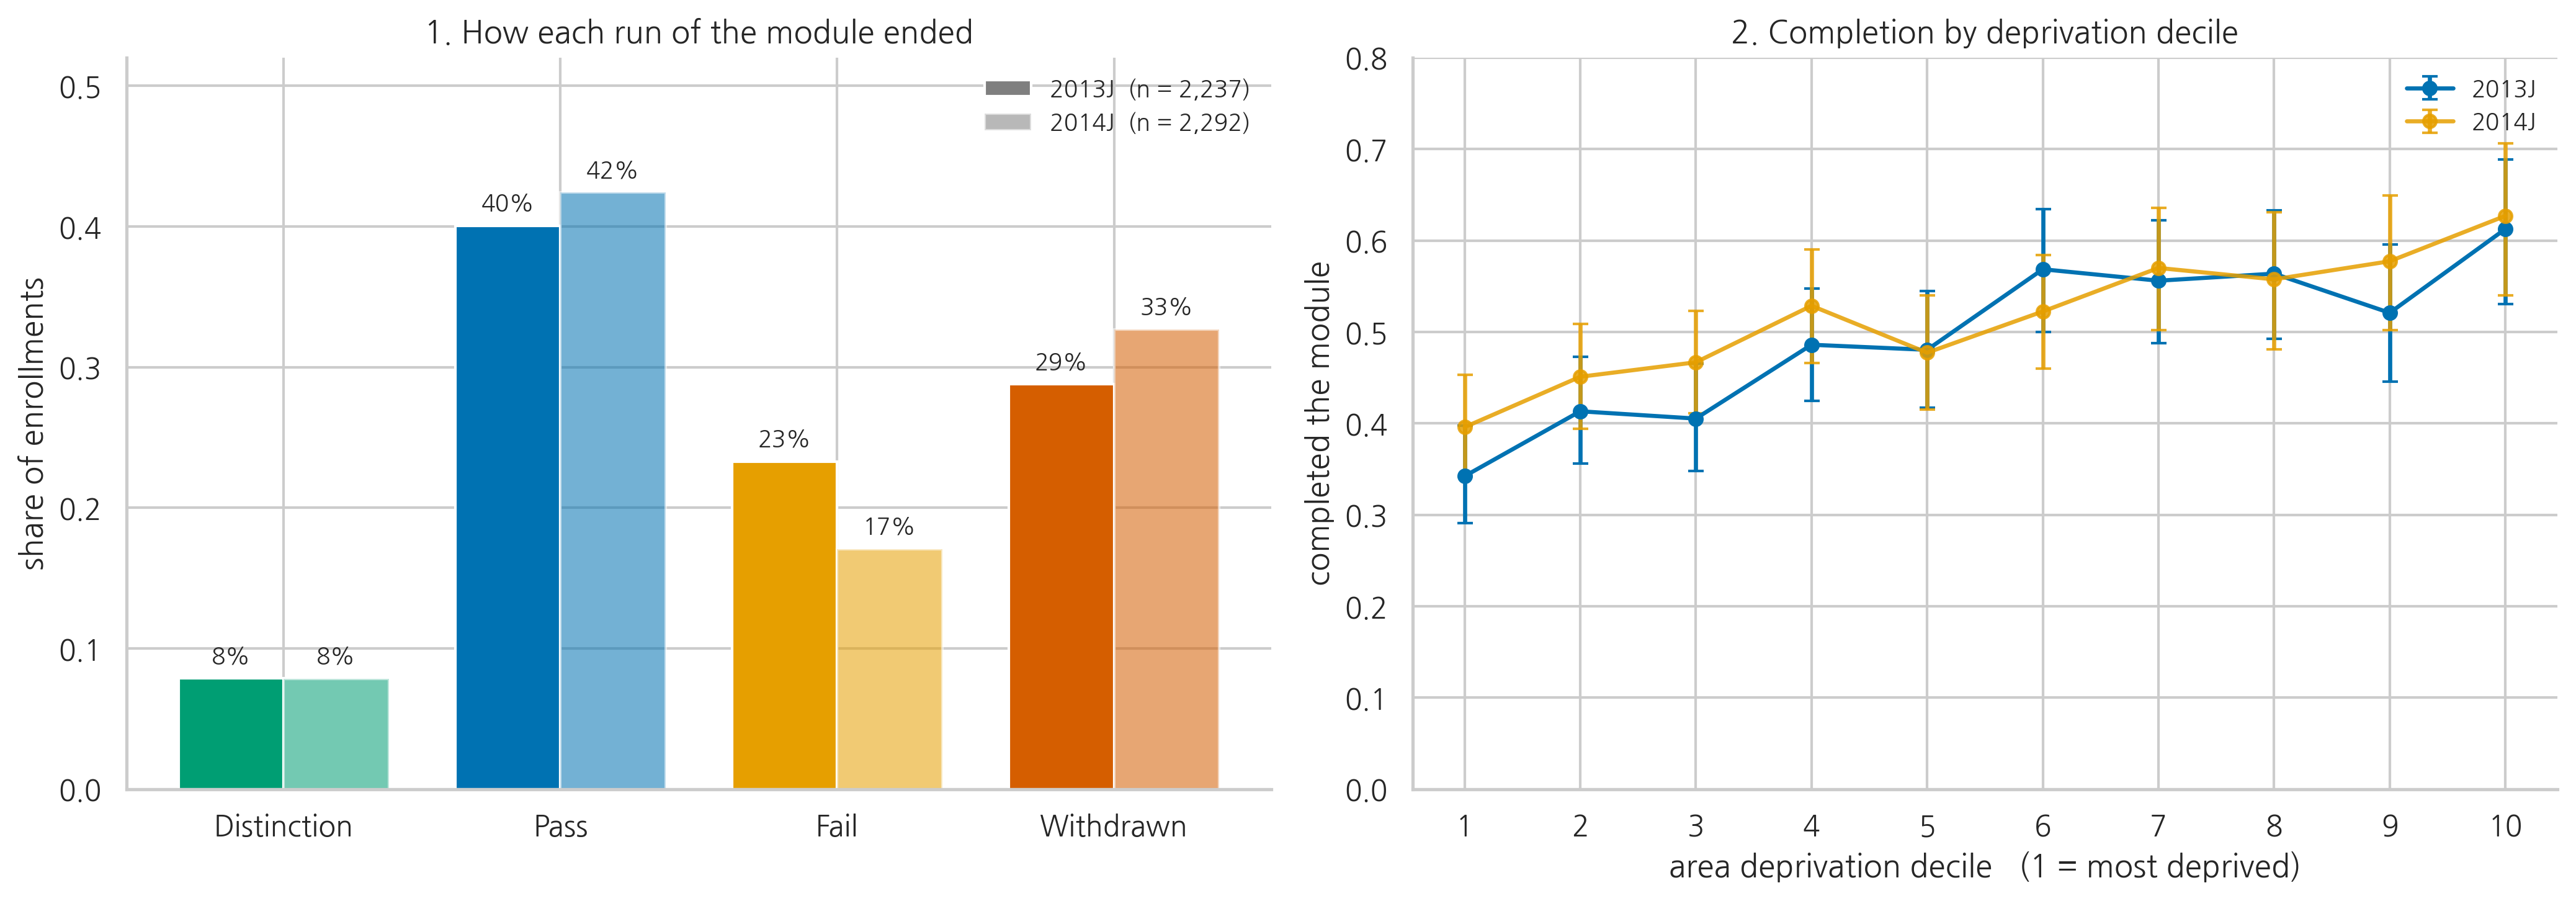


  29 enrollments have no band and are not on chart 2. That is decision 1.


In [3]:
def wilson(k, n, z=1.96):
    """A 95 percent interval for a proportion that behaves near 0 and 1."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    d = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / d
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return (centre - half, centre + half)


PRES = ["2013J", "2014J"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- chart 1: how each run ended -------------------------------------------
ax = axes[0]
order = ["Distinction", "Pass", "Fail", "Withdrawn"]
colors = [GREEN, BLUE, ORANGE, VERM]
width = 0.38
for i, pres in enumerate(PRES):
    sub = dash[dash["code_presentation"] == pres]
    shares = [(sub["final_result"] == o).mean() for o in order]
    ax.bar(np.arange(4) + (i - 0.5) * width, shares, width,
           color=colors, alpha=1.0 if i == 0 else 0.55, edgecolor="white")
    for x, s in zip(np.arange(4) + (i - 0.5) * width, shares):
        ax.text(x, s + 0.008, f"{s:.0%}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(4)); ax.set_xticklabels(order)
ax.set_ylabel("share of enrollments"); ax.set_ylim(0, 0.52)
ax.set_title("1. How each run of the module ended")
# The two runs are told apart by shade, not by hue, so the legend uses grey
# swatches at the two shades rather than borrowing one outcome's color.
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=GREY, alpha=a, edgecolor="white")
           for a in (1.0, 0.55)]
ax.legend(handles, [f"{p}  (n = {len(dash[dash['code_presentation'] == p]):,})"
                    for p in PRES], frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# ---- chart 2: completion by deprivation decile ------------------------------
ax = axes[1]
print("  Completion by deprivation decile, with the group sizes behind each point")
print()
for i, pres in enumerate(PRES):
    sub = dash[(dash["code_presentation"] == pres) & dash["imd_decile"].notna()]
    xs, ys, los, his = [], [], [], []
    for d in range(1, 11):
        g = sub[sub["imd_decile"] == d]
        if len(g) == 0:
            continue
        k, n = int(g["completed"].sum()), len(g)
        lo, hi = wilson(k, n)
        xs.append(d); ys.append(k / n); los.append(k / n - lo); his.append(hi - k / n)
    ax.errorbar(xs, ys, yerr=[los, his], marker="o", ms=5, capsize=3, lw=1.6,
                color=BLUE if i == 0 else ORANGE, label=pres,
                alpha=1.0 if i == 0 else 0.85)
    sizes = [int((sub["imd_decile"] == d).sum()) for d in range(1, 11)]
    print(f"      {pres}   most deprived decile {ys[0]:.1%}   least deprived {ys[-1]:.1%}"
          f"   group sizes {min(sizes)} to {max(sizes)}")
ax.set_xticks(range(1, 11))
ax.set_xlabel("area deprivation decile   (1 = most deprived)")
ax.set_ylabel("completed the module"); ax.set_ylim(0, 0.8)
ax.set_title("2. Completion by deprivation decile")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout(); plt.show()

print()
print(f"  {n_imd_missing} enrollments have no band and are not on chart 2. "
      f"That is decision 1.")

**Let's look at the output.**

Chart 2 rises in both runs, and it is a different kind of finding from chart 1.

Nothing in the clickstream produced that gradient (i.e., the steady rise across the deciles). A deprivation decile is a property of the neighborhood a student lived in, and nothing in this chart comes from anything a student did.

| | |
|---|---|
| **What the data directly show** | Recorded completion in this module rose across the ten area-deprivation deciles in both runs, on decile groups printed above the chart |
| **A plausible interpretation** | Study conditions that a neighborhood index partly stands in for, such as hours of paid work, quiet space, connectivity, and the cost of materials; features of how this module was taught, assessed, and supported; who chose to register in each area in the first place |
| **What these files cannot establish** | Which of those produced the gradient, and anything about the students as people. The index scores an area rather than a person, and the file records nothing about the household |

Two questions:

1. What would it mean for a module team to put chart 2 on a screen every Monday? Work through the order before your answer reaches any sentence about the students: what the record could not see, what this module's design and schedule would produce, what is true of adult distance learners in employment that no column here records, and the student last, and only as one candidate among several.

2. Chart 1 separates Withdrawn from Fail, where most dashboards merge the two into "not passing." What is one teaching decision that would change depending on which of those two a student is heading for?

## Part C. The early warning panel

The class overview describes the module. This panel names people.

A model reads the first 30 days and the first assignment and gives each enrollment a predicted probability (i.e., a number between 0 and 1 for how likely the model thinks that outcome is) of ending in Fail or Withdrawn. The panel then shows the 150 highest.

That 150 is a caseload (i.e., a work quota, not a diagnosis). The model ranks everybody and the caseload draws the line, so nobody decided that 150 students are in trouble.

Three things about how this is done, because each is a design choice:

- **Every score is out of sample** (i.e., each enrollment is scored by a model trained on the other four fifths, so nobody is scored by a model that saw how their own term ended).
- **It is a prediction about a registry outcome**, not a probability about anybody's future.
- **The panel is compared against the simplest rule that would replace it**, not against chance. A list that is right 97 percent of the time sounds like a model working until you see what one column would have done.

The model is a logistic regression (i.e., it weights each column, adds them up, and turns the total into a probability). The card prints one weight per column, per standard deviation (i.e., per one typical amount of movement in that column).

**Run the cell below.** It fits the model, prints a short card, and prints the top of the list.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

FEATURES = ["clicks_first30", "tma1_score_filled", "tma1_submitted"]
LABEL = {"clicks_first30":    "Clicks recorded, days 0 to 29",
         "tma1_score_filled": "Assignment 1 score",
         "tma1_submitted":    "Assignment 1 was submitted"}
CASELOAD = 150

term   = dash[dash["code_presentation"] == FOCAL_TERM].reset_index(drop=True).copy()
y_true = term["did_not_pass"].to_numpy()
X      = term[FEATURES].to_numpy(dtype=float)

pipe   = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
scores = cross_val_predict(pipe, X, y_true,
                           cv=StratifiedKFold(5, shuffle=True, random_state=8100),
                           method="predict_proba")[:, 1]
coefs  = pipe.fit(X, y_true)[-1].coef_[0]

def flag_top_k(s, k):
    """The caseload rule: flag the k highest scores. Ties are broken by row order."""
    f = np.zeros(len(s), dtype=int)
    f[np.argsort(-s, kind="stable")[:k]] = 1
    return f

flags = flag_top_k(scores, CASELOAD)

tp     = int(((flags == 1) & (y_true == 1)).sum())
fp     = int(((flags == 1) & (y_true == 0)).sum())
missed = int(((flags == 0) & (y_true == 1)).sum())

print("=" * 76)
print("  MODEL CARD")
print("=" * 76)
print(f"  Presentation .............. BBB {FOCAL_TERM}, {len(term):,} enrollments")
print( "  What it reads ............. " + "; ".join(LABEL[f] for f in FEATURES))
print(f"  How far it looks .......... days 0 to {EARLY_WINDOW - 1}, plus assignment 1")
print( "  How it is fitted .......... logistic regression, scored out of sample in 5 folds")
print(f"  Who lands on the list ..... the {CASELOAD} highest predicted probabilities")
print( "  What it predicts .......... whether the registry closed the enrollment as Fail")
print( "                              or Withdrawn")
print(f"  How common that is ........ {y_true.mean():.1%}, "
      f"{y_true.sum():,} of {len(term):,} enrollments")
print()
print( "  What each column does to the score, per standard deviation:")
for f, c in zip(FEATURES, coefs):
    print(f"      {LABEL[f]:<30} {c:+.3f}   a higher value "
          f"{'raises' if c > 0 else 'lowers'} the score")
print()
print("  HOW THE LIST PERFORMS")
print(f"      of the {CASELOAD} names, ended in Fail or Withdraw ..... {tp}   ({tp / CASELOAD:.1%})")
print(f"      of the {CASELOAD} names, went on to complete ........... {fp}")
print(f"      ended in Fail or Withdraw and never named ..... {missed:,} of {int(y_true.sum()):,}")
print(f"      so the list names this share of them .......... {tp / y_true.sum():.1%}")
print("=" * 76)

  MODEL CARD
  Presentation .............. BBB 2013J, 2,237 enrollments
  What it reads ............. Clicks recorded, days 0 to 29; Assignment 1 score; Assignment 1 was submitted
  How far it looks .......... days 0 to 29, plus assignment 1
  How it is fitted .......... logistic regression, scored out of sample in 5 folds
  Who lands on the list ..... the 150 highest predicted probabilities
  What it predicts .......... whether the registry closed the enrollment as Fail
                              or Withdrawn
  How common that is ........ 52.1%, 1,165 of 2,237 enrollments

  What each column does to the score, per standard deviation:
      Clicks recorded, days 0 to 29  -0.302   a higher value lowers the score
      Assignment 1 score             -1.555   a higher value lowers the score
      Assignment 1 was submitted     -0.173   a higher value lowers the score

  HOW THE LIST PERFORMS
      of the 150 names, ended in Fail or Withdraw ..... 146   (97.3%)
      of the 150 names, w

### The panel itself

Four charts. The first two are about the ranking the dashboard is about to print, and the second two are about who is on the list.

**Run the cell below.**

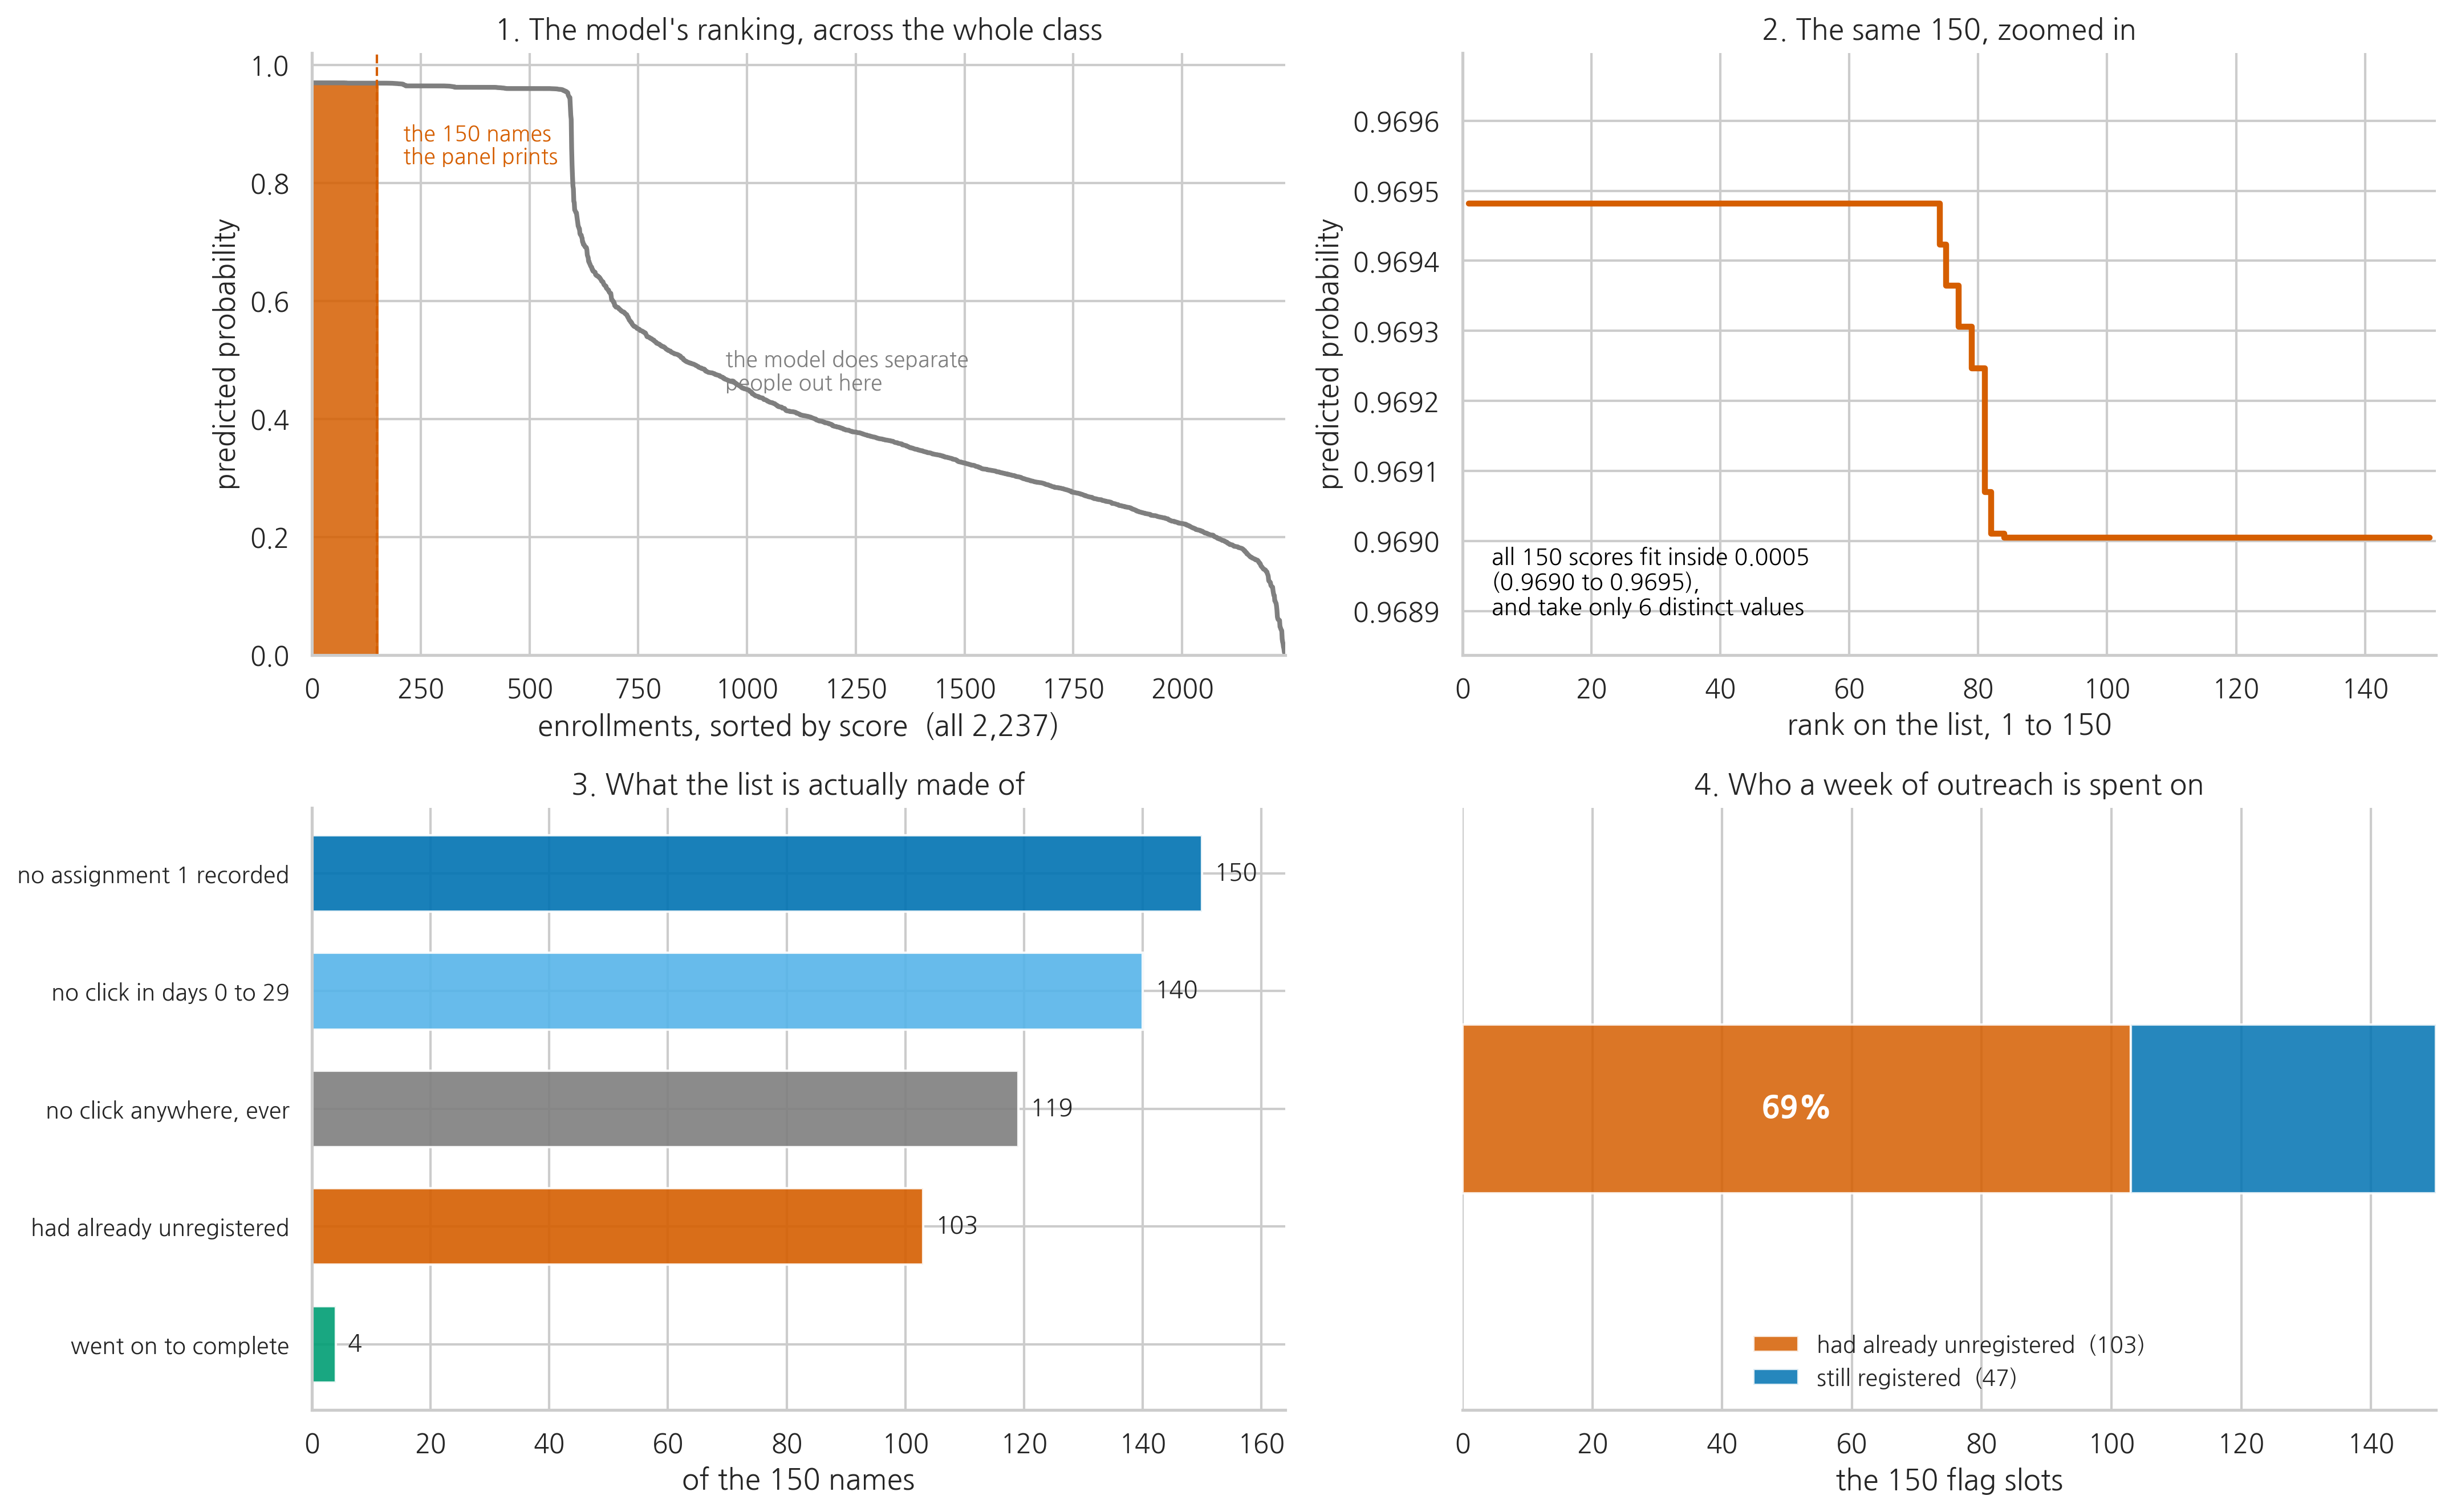

  Chart 1 shows a model that does separate people, and a list drawn from the
  one stretch where it does not. Chart 2 is that stretch at its own scale.
  Chart 3 is what a teacher could have been told instead of a rank.


In [5]:
# two counts the panel annotates, computed here and reported in full below
tie_block = int(((term["clicks_first30"] == 0) & (term["tma1_submitted"] == 0)).sum())
already_gone = (term["left_before_day_1"] == 1).to_numpy()
gone_flagged = int(flags[already_gone].sum())

srt = np.sort(scores)[::-1]          # every enrollment, highest score first
top = srt[:CASELOAD]                 # the 150 the panel prints

fig, axes = plt.subplots(2, 2, figsize=(14.5, 9))

# ---- 1. the whole class, sorted -------------------------------------------
ax = axes[0, 0]
ax.plot(np.arange(1, len(srt) + 1), srt, color=GREY, lw=2)
ax.fill_between(np.arange(1, CASELOAD + 1), 0, top, color=VERM, alpha=0.85)
ax.axvline(CASELOAD, color=VERM, lw=1, ls="--")
ax.text(CASELOAD + 60, 0.90, f"the {CASELOAD} names\nthe panel prints",
        fontsize=9, color=VERM, va="top")
ax.text(950, 0.45, "the model does separate\npeople out here", fontsize=9, color=GREY)
ax.set_xlim(0, len(srt)); ax.set_ylim(0, 1.02)
ax.set_xlabel(f"enrollments, sorted by score  (all {len(term):,})")
ax.set_ylabel("predicted probability")
ax.set_title("1. The model's ranking, across the whole class")
ax.spines[["top", "right"]].set_visible(False)

# ---- 2. the same 150, zoomed to their actual range -------------------------
ax = axes[0, 1]
ax.step(np.arange(1, CASELOAD + 1), top, where="post", color=VERM, lw=2.5)
span = top[0] - top[-1]
ax.set_ylim(top[-1] - span * 0.35, top[0] + span * 0.45)
ax.set_xlim(0, CASELOAD + 1)
ax.set_xlabel(f"rank on the list, 1 to {CASELOAD}")
ax.set_ylabel("predicted probability")
ax.set_title("2. The same 150, zoomed in")
ax.annotate(f"all {CASELOAD} scores fit inside {span:.4f}\n"
            f"({top[-1]:.4f} to {top[0]:.4f}),\n"
            f"and take only {len(set(np.round(top, 4)))} distinct values",
            xy=(0.03, 0.06), xycoords="axes fraction", fontsize=9.5, color="black", va="bottom")
ax.spines[["top", "right"]].set_visible(False)

# ---- 3. what the 150 are made of -------------------------------------------
ax = axes[1, 0]
f1 = flags == 1
rows = [("no assignment 1 recorded",  int((term.loc[f1, "tma1_submitted"] == 0).sum())),
        ("no click in days 0 to 29",  int((term.loc[f1, "clicks_first30"] == 0).sum())),
        ("no click anywhere, ever",   int((term.loc[f1, "clicks_total"] == 0).sum())),
        ("had already unregistered",  gone_flagged),
        ("went on to complete",       int(((flags == 1) & (y_true == 0)).sum()))]
names = [r[0] for r in rows][::-1]
vals  = [r[1] for r in rows][::-1]
cols  = [GREEN, VERM, GREY, SKY, BLUE]
ax.barh(np.arange(5), vals, color=cols, alpha=0.9, height=0.65)
for i, v in enumerate(vals):
    ax.text(v + 2, i, f"{v}", va="center", fontsize=10)
ax.set_yticks(np.arange(5)); ax.set_yticklabels(names, fontsize=9.5)
ax.set_xlim(0, CASELOAD + 14); ax.set_xlabel(f"of the {CASELOAD} names")
ax.set_title("3. What the list is actually made of")
ax.spines[["top", "right"]].set_visible(False)

# ---- 4. who a week of outreach is spent on ---------------------------------
ax = axes[1, 1]
still = CASELOAD - gone_flagged
ax.barh([0], [gone_flagged], color=VERM, alpha=0.85, height=0.42,
        label=f"had already unregistered  ({gone_flagged})")
ax.barh([0], [still], left=[gone_flagged], color=BLUE, alpha=0.85, height=0.42,
        label=f"still registered  ({still})")
ax.text(gone_flagged / 2, 0, f"{gone_flagged / CASELOAD:.0%}", ha="center", va="center",
        color="white", fontsize=13, weight="bold")
ax.set_xlim(0, CASELOAD); ax.set_yticks([]); ax.set_ylim(-0.75, 0.75)
ax.set_xlabel(f"the {CASELOAD} flag slots")
ax.set_title("4. Who a week of outreach is spent on")
ax.legend(frameon=False, fontsize=9.5, loc="lower center")
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout(); plt.show()

print(f"  Chart 1 shows a model that does separate people, and a list drawn from the")
print(f"  one stretch where it does not. Chart 2 is that stretch at its own scale.")
print(f"  Chart 3 is what a teacher could have been told instead of a rank.")

### Three things the panel does not show the teacher

The cell below computes them. None is visible on the dashboard itself.

The last one is the question a vendor (i.e., the company selling the dashboard) does not ask. Not whether the model is accurate, and not whether it is fair, but whether it is doing anything that a single column was not already doing.

In [6]:
# 1. the same names, the same data, five different random splits
appearances = pd.Series(0, index=term["id_student"])
for seed in [1, 2, 3, 4, 5]:
    s = cross_val_predict(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
                          X, y_true, cv=StratifiedKFold(5, shuffle=True, random_state=seed),
                          method="predict_proba")[:, 1]
    picked = flag_top_k(s, CASELOAD)
    appearances[term.loc[picked == 1, "id_student"]] += 1
ever   = appearances[appearances > 0]
always = int((ever == 5).sum())
tie_block = int(((term["clicks_first30"] == 0) & (term["tma1_submitted"] == 0)).sum())

# 2. how many flag slots go to enrollments that had already unregistered
already_gone = (term["left_before_day_1"] == 1).to_numpy()
gone_flagged = int(flags[already_gone].sum())

# 3. the model against the one column every name on the list shares
rule = (term["tma1_submitted"] == 0).to_numpy()
rule_n, rule_bad = int(rule.sum()), int(y_true[rule].sum())
lo, hi = wilson(tp, CASELOAD)

print("=" * 76)
print(f"1. THE MODEL CANNOT TELL {tie_block} OF THEM APART")
print("=" * 76)
print(f"   Enrollments with no clicks in days 0 to 29 and no assignment 1 ... {tie_block}")
print("   All of their feature values are identical, so their scores differ only in")
print("   the third and fourth decimal place, and that difference is which")
print("   cross-validation fold each one landed in.")
print()
print(f"   The same model and the same data, five different random splits:")
print(f"      on all five lists ............................ {always}")
print(f"      on some lists but not others ................. {int((ever < 5).sum())}")
print(f"      distinct enrollments appearing at least once . {len(ever)} for {CASELOAD} slots")
print("   The sort order decides who gets a phone call. The panel shows a ranked")
print("   list anyway, which is the panel asserting a precision it does not have.")

print()
print("=" * 76)
print("2. MOST OF THE WEEK IS SPENT ON PEOPLE WHO HAD ALREADY LEFT")
print("=" * 76)
print(f"   Enrollments in {FOCAL_TERM} that unregistered on or before day 0 ... "
      f"{int(already_gone.sum())}")
print(f"   How many of the {CASELOAD} flag slots they occupy ............ {gone_flagged}"
      f"   ({gone_flagged / CASELOAD:.0%})")
print("   Nothing on the panel says so, because the panel never reads the")
print("   unregistration date. That is decision 3 in Part A, arriving on a screen.")

print()
print("=" * 76)
print("3. ONE COLUMN DOES ALMOST THE WHOLE JOB")
print("=" * 76)
print(f"   Every name on the list has the same leading reason: no assignment 1")
print(f"   recorded as submitted. So ask what the regression added to that column.")
print()
print(f"      enrollments matching that one rule ........... {rule_n}")
print(f"      of those, ended in Fail or Withdraw .......... {rule_bad}   "
      f"({rule_bad / rule_n:.1%})")
print(f"      so the rule's names are right ................ {rule_bad / rule_n:.1%}")
print(f"      and the model's {CASELOAD} names are right .......... {tp / CASELOAD:.1%}")
print(f"      95% interval on those {tp} of {CASELOAD} ................. "
      f"[{lo:.1%}, {hi:.1%}]")
print()
print(f"   The rule's {rule_bad / rule_n:.1%} sits inside that interval, so at this caseload the two")
print("   cannot be told apart on precision. Chance is the wrong thing to measure")
print("   against. The one-column rule is the thing to measure against.")
print("=" * 76)

1. THE MODEL CANNOT TELL 422 OF THEM APART
   Enrollments with no clicks in days 0 to 29 and no assignment 1 ... 422
   All of their feature values are identical, so their scores differ only in
   the third and fourth decimal place, and that difference is which
   cross-validation fold each one landed in.

   The same model and the same data, five different random splits:
      on all five lists ............................ 3
      on some lists but not others ................. 418
      distinct enrollments appearing at least once . 421 for 150 slots
   The sort order decides who gets a phone call. The panel shows a ranked
   list anyway, which is the panel asserting a precision it does not have.

2. MOST OF THE WEEK IS SPENT ON PEOPLE WHO HAD ALREADY LEFT
   Enrollments in 2013J that unregistered on or before day 0 ... 336
   How many of the 150 flag slots they occupy ............ 103   (69%)
   Nothing on the panel says so, because the panel never reads the
   unregistration date. T

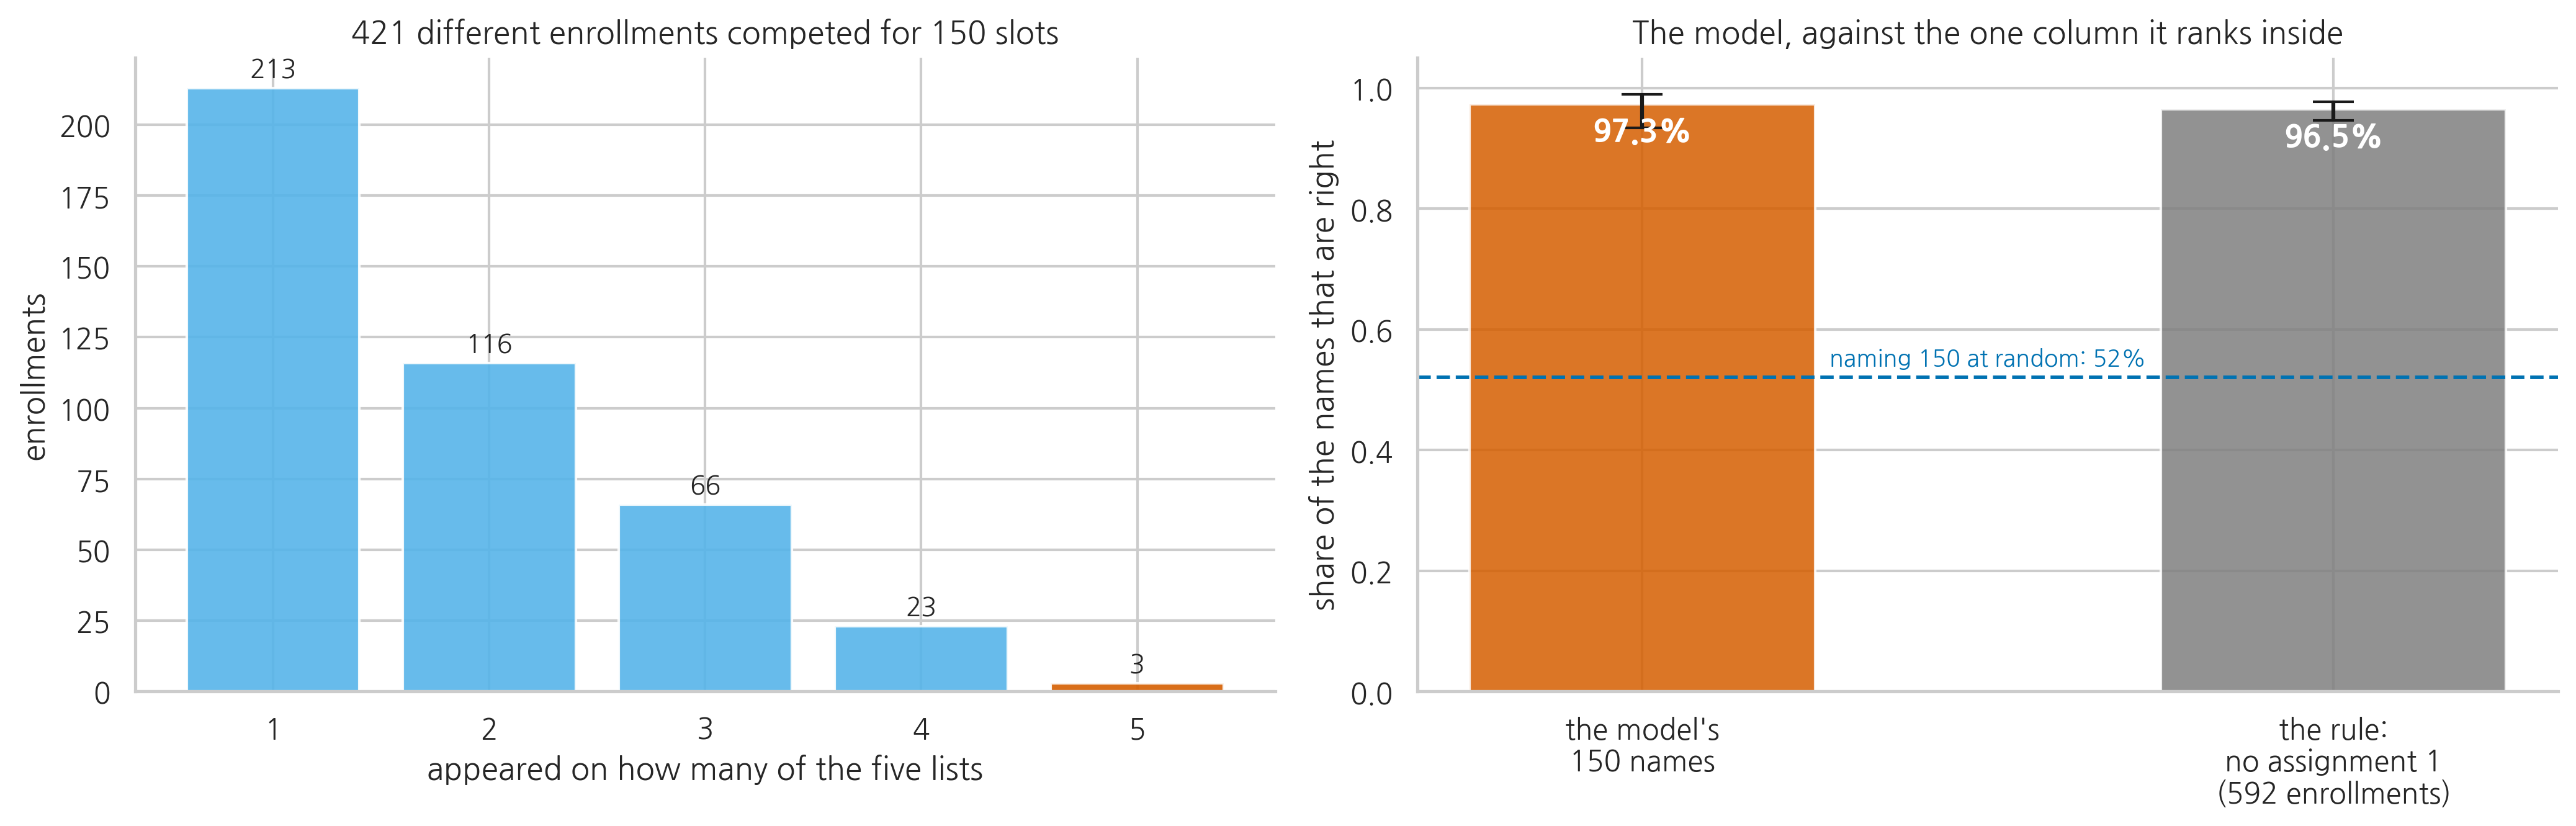

  The intervals on the right overlap, which is what 'cannot be told apart
  on precision at this caseload' looks like when you draw it.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

# ---- how often each enrollment appeared, across five random splits ----------
ax = axes[0]
counts5 = [int((ever == k).sum()) for k in range(1, 6)]
bars = ax.bar(range(1, 6), counts5, color=[SKY, SKY, SKY, SKY, VERM], alpha=0.9)
for x, v in zip(range(1, 6), counts5):
    ax.text(x, v + 4, f"{v}", ha="center", fontsize=10)
ax.set_xticks(range(1, 6))
ax.set_xlabel("appeared on how many of the five lists")
ax.set_ylabel("enrollments")
ax.set_title(f"{len(ever)} different enrollments competed for {CASELOAD} slots")
ax.spines[["top", "right"]].set_visible(False)

# ---- the model against the one column it is ranking inside ------------------
ax = axes[1]
labels = ["the model's\n150 names", f"the rule:\nno assignment 1\n({rule_n} enrollments)"]
vals   = [tp / CASELOAD, rule_bad / rule_n]
lo_hi  = [wilson(tp, CASELOAD), wilson(rule_bad, rule_n)]
errs   = [[v - l for v, (l, h) in zip(vals, lo_hi)],
          [h - v for v, (l, h) in zip(vals, lo_hi)]]
ax.bar(labels, vals, yerr=errs, capsize=8, color=[VERM, GREY], alpha=0.85, width=0.5)
for x, v in enumerate(vals):
    ax.text(x, v - 0.06, f"{v:.1%}", ha="center", color="white", fontsize=12, weight="bold")
ax.axhline(y_true.mean(), color=BLUE, ls="--", lw=1.4)
ax.text(0.5, y_true.mean() + 0.02, f"naming {CASELOAD} at random: {y_true.mean():.0%}",
        ha="center", fontsize=9, color=BLUE)
ax.set_ylim(0, 1.05); ax.set_ylabel("share of the names that are right")
ax.set_title("The model, against the one column it ranks inside")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout(); plt.show()

print("  The intervals on the right overlap, which is what 'cannot be told apart")
print("  on precision at this caseload' looks like when you draw it.")

**Let's look at the output.** Three questions, one per finding.

1. The model cannot separate the enrollments with no clicks and no assignment 1, and the sort order (i.e., which row happened to come first) decides which of them is contacted. What might the screen say instead of a rank, and what does your change cost?

2. Most of a week of outreach goes to enrollments that had already unregistered. Where in Part A did that become possible, and what would have had to change there?

3. The model and the one-column rule (i.e., flag everybody with no assignment 1 recorded, no model at all) cannot be told apart on precision (i.e., the share of printed names that turn out to be right) at this caseload. Which of those two would a teacher notice first, and which would a vendor report?

A fourth, if there is time. This panel names a small share of the enrollments that go on to fail or withdraw, and hears nothing at all about the rest. Whether the people behind those names wanted a phone call is a question no column here answers.

## Your turn: the critique table

Please fill this in. Double click this cell to edit it, replace the bracketed text, and keep each entry to one or two sentences.

Two constraints. In the action column, please name something a teacher or module team could do on a Monday: send a specific message, change a specific activity, reorganize a specific ten minutes of a tutorial (i.e., a small-group teaching session). "Monitor the student" is not an action. In the misleads column, please name a specific person or group who gets the wrong end of it, using evidence from the printouts above.

| Panel | What a teacher would do | What could mislead them, and who pays |
|---|---|---|
| **B. Class overview** | [your answer] | [your answer] |
| **C. Early warning** | [your answer] | [your answer] |

Then one short answer.

**van Leeuwen, Teasley, and Wise (2022) separate teacher-facing from student-facing analytics** (i.e., built for whoever teaches the course, against built for a student to read about themselves), and argue they are not the same tool with different logins. Please take one element of either panel and say what would have to change before a student could see it, and what harm the unchanged version would do.

*[your answer]*

---

## Filled in, for the instructor

One defensible set of answers rather than the answers. What makes them work is that every claim carries a number from the printouts and every action names somebody who acts. A student answer that reaches different conclusions from the same numbers is doing the assignment correctly.

### B. Class overview

**What a teacher would do.** Take chart 2 to the module team's Monday planning slot and change one thing the module controls: move the assignment 1 deadline off the week most students are paid, or cover the cost of the materials students currently buy. The chart names a condition, so the action has to sit at the level of the module rather than the student.

**What could mislead them, and who pays.** It invites the opposite reading, that students in decile 1 are less able or less committed, and nothing on the screen carries the caveat. A tutor who reads it in thirty seconds can leave with a sentence about a kind of student. The 29 enrollments with no band are not on the line at all, so the chart is also silent about the one group it could not place.

### C. Early warning

**What a teacher would do.** Work the 150 names during the week, starting with the ones who submitted assignment 1 and then stopped, because those are the cases where a phone call still has something to offer.

**What could mislead them, and who pays.** 103 of the 150 had already unregistered on or before day 0, so roughly two thirds of the week goes to people who have gone, and the panel never says so. 422 enrollments are identical to the model, so which of them appears is decided by row order: a tutor reads a ranked list and infers that the first name is in more trouble than the hundredth, and they are the same record. The people who pay are the 1,019 who ended in Fail or Withdraw and were never named.

### The short answer

Take the risk score from Panel C. Before a student could see it, the number itself would have to go, and the reference frame would have to move from the class to the student's own record: what they have submitted, what is due next, and by when.

The score is a probability about them built from thirty days of clicks and one assignment, and a student can neither change the input retroactively nor question the output. Unchanged, it tells a student that a system has already predicted their failure, which is a claim this file cannot support about any individual, since 422 enrollments carry the same three values and the model cannot tell them apart.

The harm falls hardest on the student who would have finished: four of the 150 completed the module, and being told that you are on a risk list is its own intervention.

## Build it by vibe coding

The critique table says what this dashboard should have been. This is where you build that version, and you do not write the code.

Two steps, and neither one asks you to describe the data from memory.

**Step 1. Have the prompt written for you.** Run the cell below. It prints a summary of what this notebook established: the three decisions, the numbers behind each panel, and the three things the panel does not show. Copy the whole block, paste it into any AI assistant, and ask it to turn the block into a build prompt for a single-page teacher-facing dashboard. Ask it for a prompt, not for code.

**Step 2. Build it.** Paste that prompt into Claude and let it build the page. Claude returns something you can click, so you can see whether the design survives contact with the numbers. Read what it made, then change one thing in the prompt and run it again.

**Three things to check against the printout.** The tool has none of Part A's decisions except what your prompt carries.

1. The denominator under each panel (i.e., what number each share was computed out of), and whether the screen says anywhere that some rows are missing.
2. Whether a title names a recorded event or a kind of person. "Students who dropped out" and "enrollments with an unregistration date" are different claims about the same column.
3. Whether anything on the screen shows that 422 enrollments are indistinguishable to the model.

A panel that renders is not yet a panel that is true of these records.

In [8]:
# =========================================================================
# A summary of this notebook, ready to paste into an AI tool.
# Run this cell, then copy everything between the two rules.
# =========================================================================
foc = dash[dash["code_presentation"] == FOCAL_TERM]
d1  = foc.loc[foc["imd_decile"] == 1,  "completed"].mean()
d10 = foc.loc[foc["imd_decile"] == 10, "completed"].mean()

print("-" * 76)
print(f"""CONTEXT FOR A DASHBOARD BUILD

THE DATA. Open University Learning Analytics Dataset (OULAD), module BBB,
presentation {FOCAL_TERM}: {len(term):,} enrollments, one row each. The file holds
clicks per day, assessment submissions, registration and unregistration dates,
banded demographics, and how the registry closed the enrollment. Published
under CC BY 4.0 by Kuzilek, Hlosta and Zdrahal (2017).

THE AUDIENCE. A module team with one week of outreach time.

WHAT IS ALREADY DECIDED ABOUT THESE FILES:
 - The deprivation column is an area measure, not a measure of a person, and
   {n_imd_missing} enrollments have no band at all.
 - {n_no_clicks} of {len(dash):,} enrollments have no clickstream row anywhere. A 0 in
   the table is a measurement; an absence is not.
 - {n_no_tma1:,} have no assignment 1 score, so the score is absent, not low.
 - {n_gone} enrollments unregistered on or before day 0 and are still in the table.

WHAT THE TWO PANELS SHOWED:
 - Recorded completion rises across the area-deprivation deciles, from
   {d1:.1%} in the most deprived to {d10:.1%} in the least. The index scores an
   area, not a person, and nothing in the clickstream produced that gradient.
 - At a caseload of {CASELOAD}, the flag list is right {tp / CASELOAD:.1%} of the time and
   names {tp / y_true.sum():.1%} of the enrollments that end in Fail or Withdraw.
 - {tie_block} enrollments have identical feature values, so the model cannot tell
   them apart, and {gone_flagged} of the {CASELOAD} names had already unregistered.
 - The rule "no assignment 1 recorded as submitted" is right {rule_bad / rule_n:.1%} of the
   time on {rule_n} enrollments, with no model at all.
""")
print("-" * 76)
print()
print("  Paste everything between the rules into an AI assistant and ask it to")
print("  turn the block into a build prompt for a single-page teacher-facing")
print("  dashboard. Ask it for a prompt, not for code. Then take that prompt")
print("  to Claude and have it build the page.")

----------------------------------------------------------------------------
CONTEXT FOR A DASHBOARD BUILD

THE DATA. Open University Learning Analytics Dataset (OULAD), module BBB,
presentation 2013J: 2,237 enrollments, one row each. The file holds
clicks per day, assessment submissions, registration and unregistration dates,
banded demographics, and how the registry closed the enrollment. Published
under CC BY 4.0 by Kuzilek, Hlosta and Zdrahal (2017).

THE AUDIENCE. A module team with one week of outreach time.

WHAT IS ALREADY DECIDED ABOUT THESE FILES:
 - The deprivation column is an area measure, not a measure of a person, and
   29 enrollments have no band at all.
 - 738 of 4,529 enrollments have no clickstream row anywhere. A 0 in
   the table is a measurement; an absence is not.
 - 1,112 have no assignment 1 score, so the score is absent, not low.
 - 576 enrollments unregistered on or before day 0 and are still in the table.

WHAT THE TWO PANELS SHOWED:
 - Recorded completion 